In [30]:
# ==============================================================================
# SÉRIES TEMPORAIS — Superfície de Água: Belo Horizonte / MG (1985–2024)
# Especialização em Métodos Matemáticos Aplicados (CEMMA)
# Profa. Sheila Regina Oro
# Dados: Projeto MapBiomas Água — Coleção 4
# ==============================================================================

# Instalar pacotes necessários (executar apenas na 1ª vez)
# install.packages(c("readxl", "dplyr", "forecast", "tseries"))

library(readxl)
library(dplyr)
library(forecast)
library(tseries)

# Diretório para as figuras do artigo
dir.create("figuras", showWarnings = FALSE)

# Helper: salva o plot atual como PNG com fundo BRANCO, independente do tema do editor.
# Usa recordPlot() para capturar o gráfico inline e replayPlot() para
# reproduzi-lo num dispositivo PNG com fundo branco forçado.
# Chamar DEPOIS de cada comando de plot, antes do próximo plot.
salvar_fig <- function(nome, width = 1400, height = 800, res = 150) {
  p <- recordPlot()                        # captura o plot do dispositivo atual
  png(filename = file.path("figuras", nome),
      width    = width,
      height   = height,
      res      = res,
      bg       = "white")                  # fundo branco explícito
  par(bg      = "white",
      fg      = "black",
      col.axis = "black",
      col.lab  = "black",
      col.main = "black",
      col.sub  = "black")
  replayPlot(p)                            # reproduz o gráfico no novo dispositivo
  dev.off()
  cat("  -> Figura salva:", file.path("figuras", nome), "\n")
}

cat("Pacotes carregados. Pasta 'figuras/' pronta.\n")
cat("R version:", R.version$major, ".", R.version$minor, "\n")


Pacotes carregados. Pasta 'figuras/' pronta.
R version: 4 . 6.0 


In [31]:
# ==============================================================================
# 1. CARGA E PREPARAÇÃO DOS DADOS
# ==============================================================================

nome_arquivo <- "STATISTICS_MAPBIOMAS_AGUA_COL4_CITY-STATE-BIOME-SUB_BASINS_DOI.xlsx"

# Leitura da aba mensal por município
dados_cidades <- read_excel(nome_arquivo, sheet = "WATER_CITY_MENSAL")

# Filtrar Belo Horizonte e ordenar por ano
dados_bh <- dados_cidades %>%
  filter(municipality == "Belo Horizonte") %>%
  arrange(year)

# Transformar a matriz de meses (jan–dez) em vetor contínuo mensal
# Cada linha do Excel é um ano; t() transpõe para obter jan85, fev85, ..., dez24
vetor_agua <- as.numeric(t(as.matrix(dados_bh %>% select(january:december))))

# Criar objeto de série temporal: mensal (frequency=12), início jan/1985
ts_bh <- ts(vetor_agua, start = c(1985, 1), frequency = 12)

cat("=== Série: Superfície de Água Mensal — Belo Horizonte (MG) ===\n")
cat(sprintf("Período  : %d/%02d  a  %d/%02d\n",
            start(ts_bh)[1], start(ts_bh)[2],
            end(ts_bh)[1],   end(ts_bh)[2]))
cat("Observações:", length(ts_bh), "\n\n")
print(summary(ts_bh))


=== Série: Superfície de Água Mensal — Belo Horizonte (MG) ===
Período  : 1985/01  a  2024/12
Observações: 480 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  213.3   238.2   258.0   276.1   316.6   399.2 


  -> Figura salva: figuras/01_serie_completa.png 


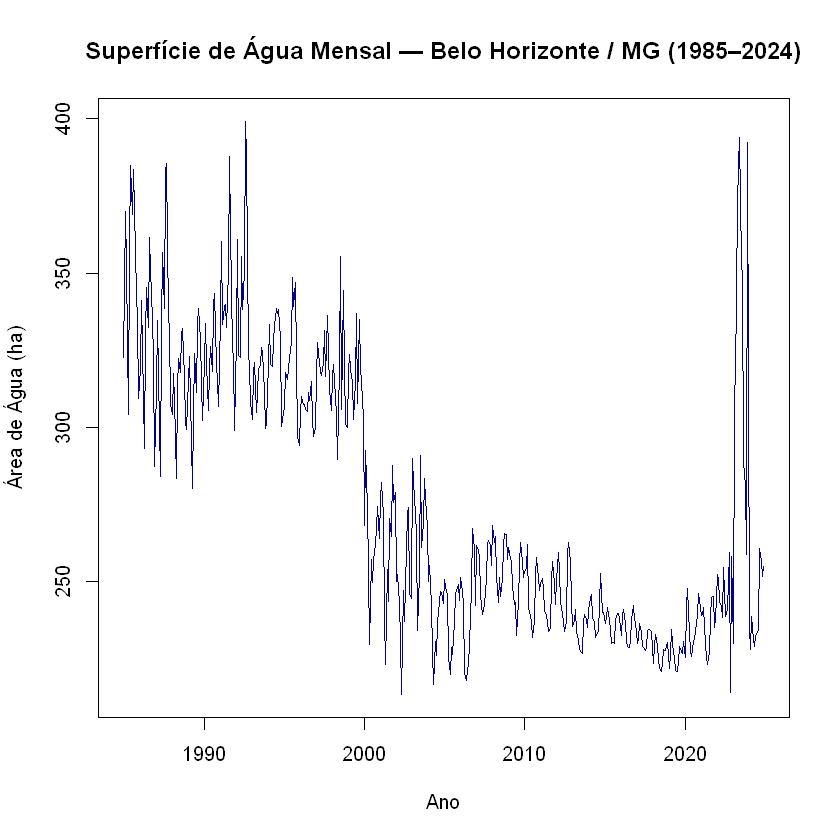

  -> Figura salva: figuras/02_periodograma_integrado.png 


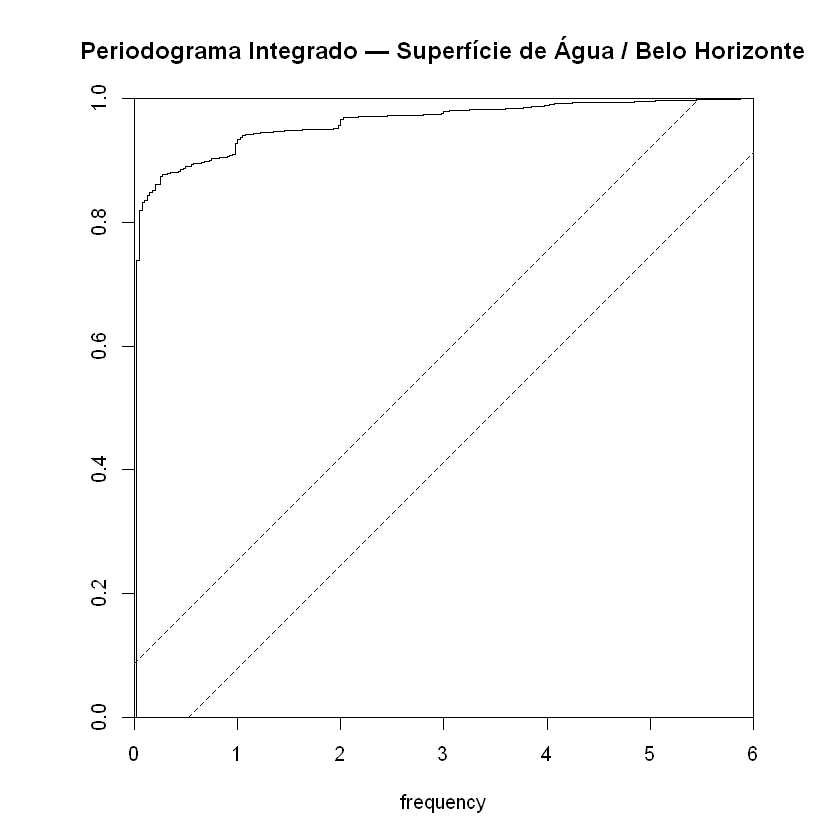

  -> Figura salva: figuras/03_decomposicao.png 


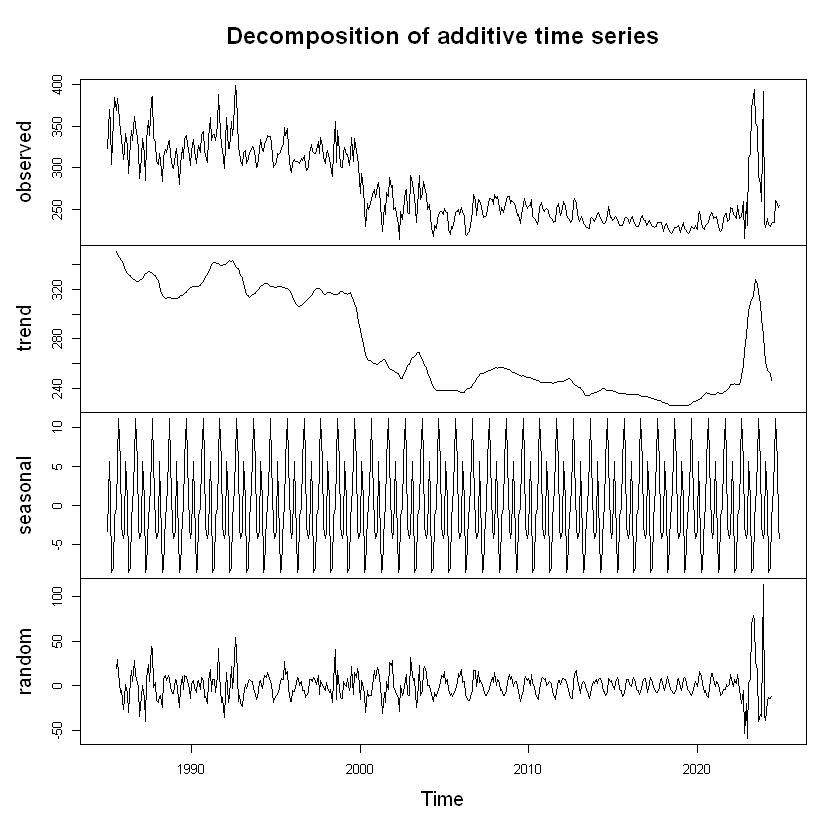

In [32]:
# ==============================================================================
# 2. ANÁLISE EXPLORATÓRIA
# ==============================================================================

# Gráfico da série completa
plot(ts_bh,
     main = "Superfície de Água Mensal — Belo Horizonte / MG (1985–2024)",
     ylab = "Área de Água (ha)", xlab = "Ano",
     col  = "darkblue", lwd  = 1.5)
salvar_fig("01_serie_completa.png")

# Periodograma integrado: detecta periodicidades e ciclos na série
cpgram(ts_bh,
       main = "Periodograma Integrado — Superfície de Água / Belo Horizonte")
salvar_fig("02_periodograma_integrado.png")

# Decomposição clássica: extrai tendência, sazonalidade e resíduo
plot(decompose(ts_bh))
salvar_fig("03_decomposicao.png", height = 1000)


In [33]:
# ==============================================================================
# 3. TESTE DE ESTACIONARIEDADE — Dickey-Fuller Aumentado (ADF)
# ==============================================================================
# H0: a série possui raiz unitária (NÃO é estacionária)
# p-valor < 0,05 → rejeitar H0 → série estacionária

cat("--- Teste ADF na série original ---\n")
adf.test(ts_bh)


--- Teste ADF na série original ---


Warning message in adf.test(ts_bh):
"p-value smaller than printed p-value"



	Augmented Dickey-Fuller Test

data:  ts_bh
Dickey-Fuller = -4.0701, Lag order = 7, p-value = 0.01
alternative hypothesis: stationary


In [34]:
# ==============================================================================
# 4. DIVISÃO TREINO / TESTE
# ==============================================================================
# Treino: jan/1985 – dez/2019  (35 anos = 420 meses)
# Teste:  jan/2020 – dez/2024  ( 5 anos =  60 meses)

ts_treino <- window(ts_bh, end   = c(2019, 12))
ts_teste  <- window(ts_bh, start = c(2020,  1))
horizonte <- length(ts_teste)

cat(sprintf("Treino : %d/%02d  até  %d/%02d  |  %d observações\n",
            start(ts_treino)[1], start(ts_treino)[2],
            end(ts_treino)[1],   end(ts_treino)[2],
            length(ts_treino)))
cat(sprintf("Teste  : %d/%02d  até  %d/%02d  |  %d observações\n",
            start(ts_teste)[1], start(ts_teste)[2],
            end(ts_teste)[1],   end(ts_teste)[2],
            length(ts_teste)))
cat("Horizonte de previsão:", horizonte, "meses\n")


Treino : 1985/01  até  2019/12  |  420 observações
Teste  : 2020/01  até  2024/12  |  60 observações
Horizonte de previsão: 60 meses


 SES — Suavização Exponencial Simples



Forecast method: Simple exponential smoothing

Model Information:
Simple exponential smoothing 

Call:
ses(y = ts_treino, h = horizonte)

  Smoothing parameters:
    alpha = 0.7385 

  Initial states:
    l = 333.2406 

  sigma:  15.2795

     AIC     AICc      BIC 
4831.175 4831.233 4843.296 

Error measures:
                     ME     RMSE      MAE        MPE     MAPE      MASE
Training set -0.3343784 15.24312 10.99482 -0.2832683 3.800057 0.9063786
                   ACF1
Training set 0.07062147

Forecasts:
         Point Forecast    Lo 80    Hi 80     Lo 95    Hi 95
Jan 2020       229.5289 209.9474 249.1104 199.58153 259.4763
Feb 2020       229.5289 205.1866 253.8712 192.30062 266.7572
Mar 2020       229.5289 201.2154 257.8424 186.22711 272.8307
Apr 2020       229.5289 197.7364 261.3214 180.90643 278.1514
May 2020       229.5289 194.6022 264.4556 176.11313 282.9447
Jun 2020       229.5289 191.7270 267.3308 171.71589 287.3419
Jul 2020       229.5289 189.0555 270.0022 167.63024 291.

  -> Figura salva: figuras/04_residuos_ses.png 


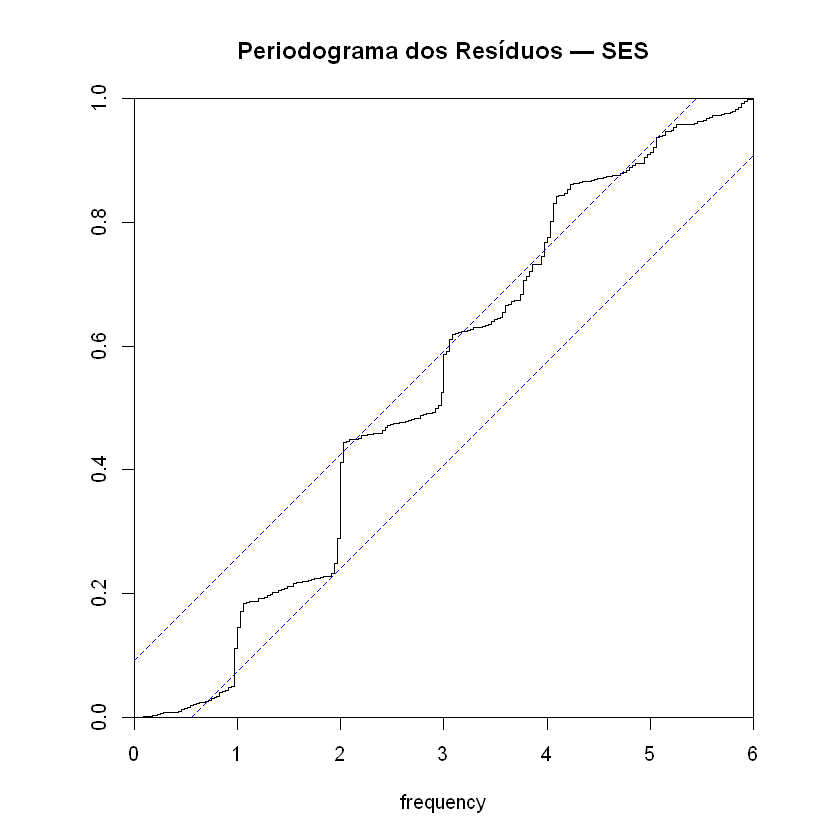


	Ljung-Box test

data:  Residuals from Simple exponential smoothing
Q* = 426.96, df = 24, p-value < 2.2e-16

Model df: 0.   Total lags used: 24

  -> Figura salva: figuras/05_diagnostico_ses.png 
 HOLT — Suavização com Tendência



Forecast method: Holt's method

Model Information:
Holt's method 

Call:
holt(y = ts_treino, h = horizonte)

  Smoothing parameters:
    alpha = 0.7287 
    beta  = 1e-04 

  Initial states:
    l = 351.0509 
    b = -0.2724 

  sigma:  15.3387

     AIC     AICc      BIC 
4836.406 4836.550 4856.607 

Error measures:
                     ME     RMSE      MAE        MPE     MAPE      MASE
Training set -0.0209687 15.26547 11.00814 -0.1655148 3.800806 0.9074766
                   ACF1
Training set 0.07103782

Forecasts:
         Point Forecast    Lo 80    Hi 80     Lo 95    Hi 95
Jan 2020       229.1190 209.4616 248.7763 199.05568 259.1822
Feb 2020       228.8457 204.5221 253.1692 191.64604 266.0453
Mar 2020       228.5724 200.3427 256.8021 185.39883 271.7460
Apr 2020       228.2991 196.6408 259.9575 179.88184 276.7164
May 2020       228.0259 193.2747 262.7771 174.87849 281.1733
Jun 2020       227.7526 190.1614 265.3438 170.26186 285.2433
Jul 2020       227.4793 187.2475 267.7112 165.950

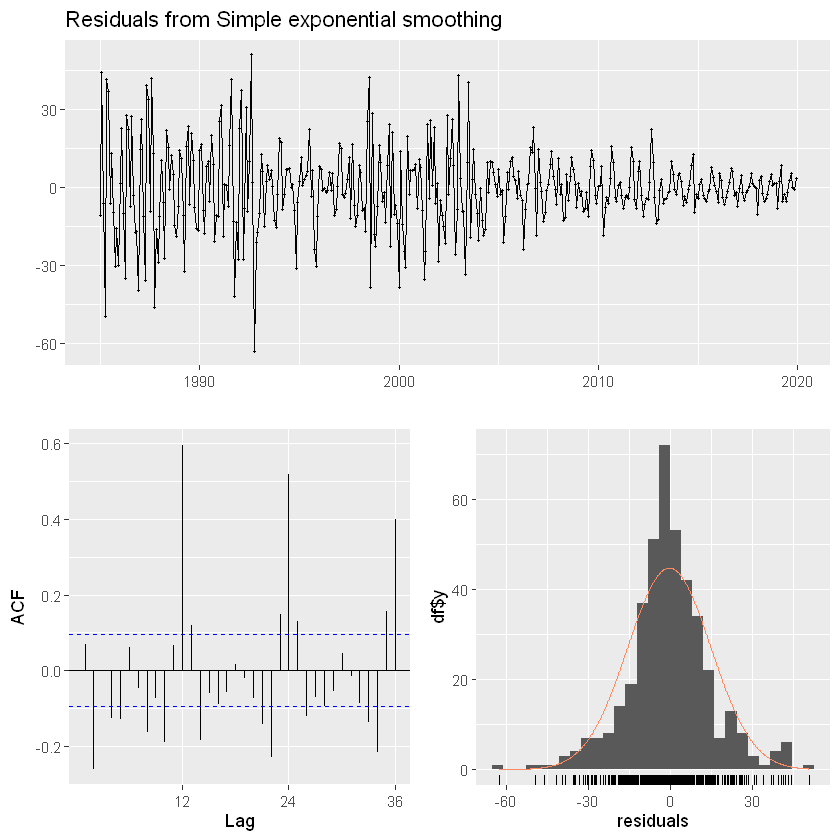

  -> Figura salva: figuras/06_residuos_holt.png 


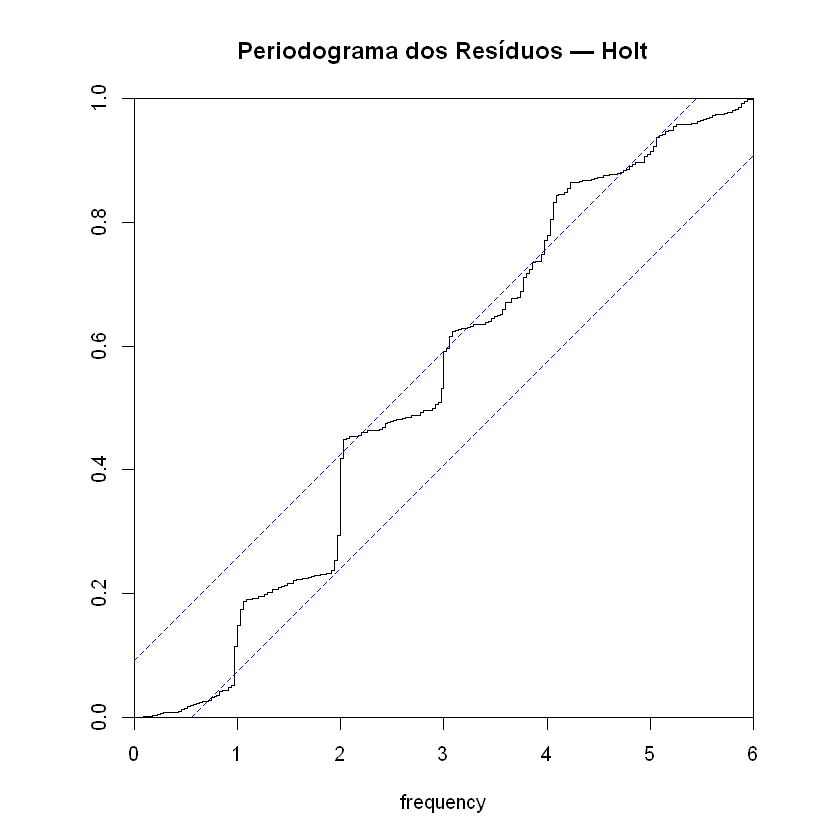


	Ljung-Box test

data:  Residuals from Holt's method
Q* = 423.02, df = 24, p-value < 2.2e-16

Model df: 0.   Total lags used: 24

  -> Figura salva: figuras/07_diagnostico_holt.png 
 HOLT-WINTERS — Tendência e Sazonalidade



Forecast method: Holt-Winters' additive method

Model Information:
Holt-Winters' additive method 

Call:
hw(y = ts_treino, h = horizonte)

  Smoothing parameters:
    alpha = 0.3957 
    beta  = 1e-04 
    gamma = 0.3462 

  Initial states:
    l = 357.3425 
    b = -0.2529 
    s = -9.7313 -2.6513 4.557 14.6134 13.1566 -4.886
           -1.9131 -10.3681 -13.3421 7.0583 12.8802 -9.3736

  sigma:  12.5814

     AIC     AICc      BIC 
4681.659 4683.182 4750.344 

Error measures:
                     ME     RMSE      MAE        MPE     MAPE      MASE
Training set -0.1259429 12.33944 9.003316 -0.1365428 3.164284 0.7422055
                  ACF1
Training set 0.2763458

Forecasts:
         Point Forecast    Lo 80    Hi 80    Lo 95    Hi 95
Jan 2020       221.7337 205.6100 237.8575 197.0746 246.3928
Feb 2020       227.4969 210.1559 244.8380 200.9761 254.0178
Mar 2020       233.4778 214.9989 251.9567 205.2168 261.7389
Apr 2020       227.9026 208.3514 247.4537 198.0016 257.8035
May 2020       

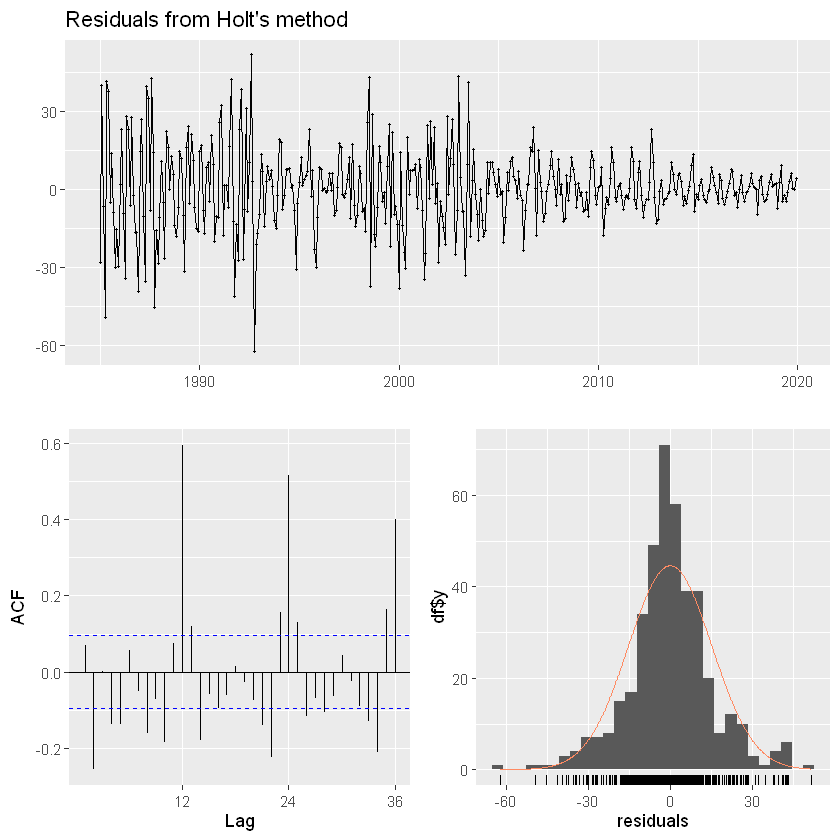

  -> Figura salva: figuras/08_residuos_hw.png 


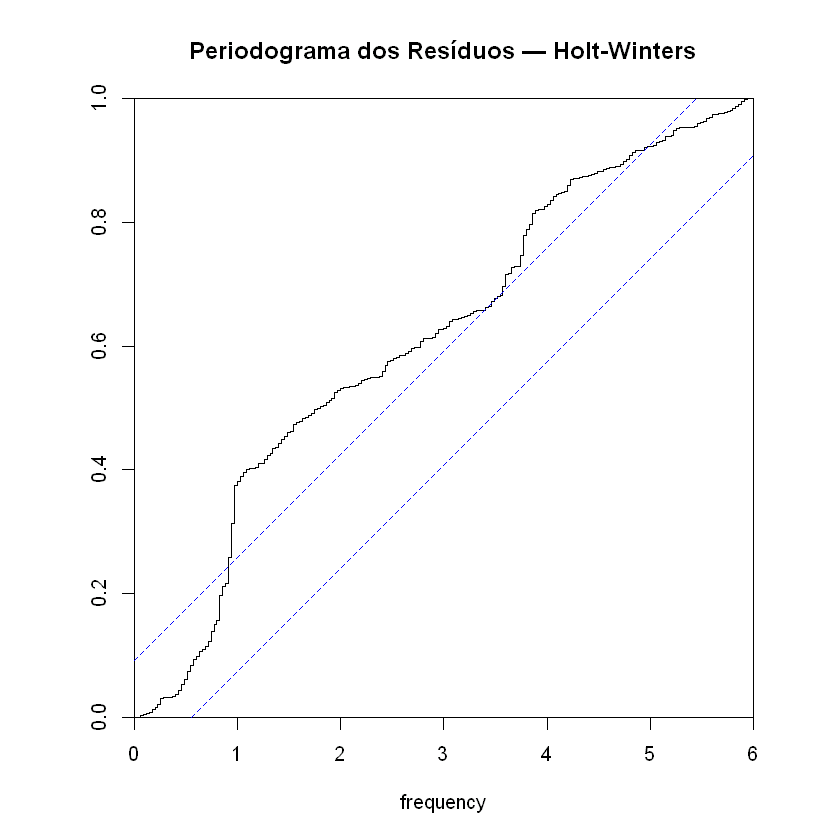


	Ljung-Box test

data:  Residuals from Holt-Winters' additive method
Q* = 242.32, df = 24, p-value < 2.2e-16

Model df: 0.   Total lags used: 24

  -> Figura salva: figuras/09_diagnostico_hw.png 


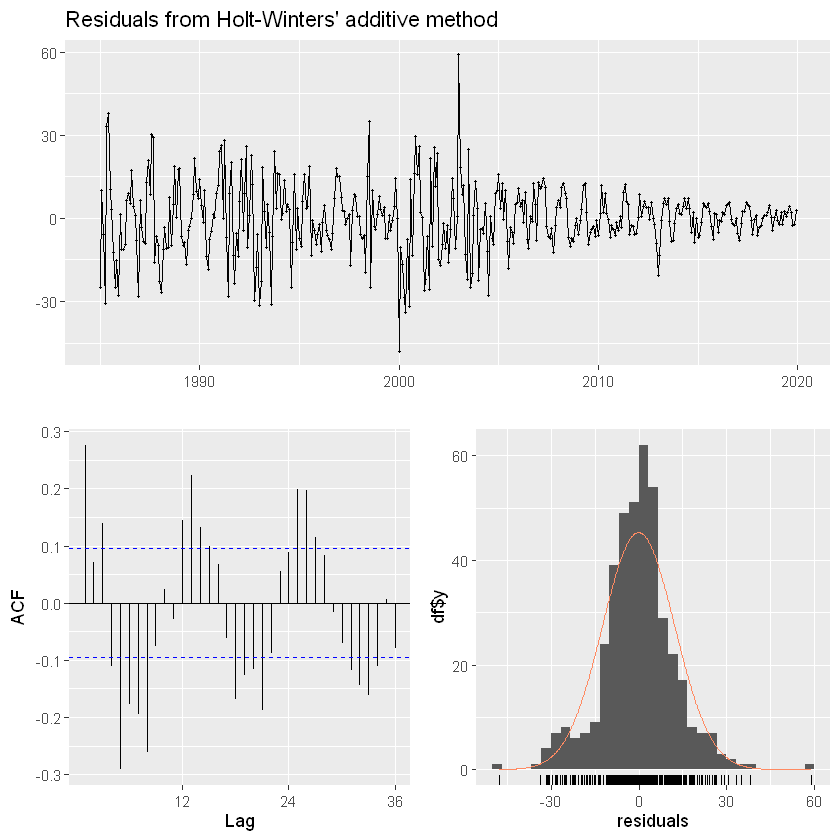

In [35]:
# ==============================================================================
# 5. MODELAGEM — Modelos de Suavização Exponencial
# ==============================================================================

# --- 5a. Suavização Exponencial Simples (SES) ---
cat("============================================================\n")
cat(" SES — Suavização Exponencial Simples\n")
cat("============================================================\n")
modelo_ses <- ses(ts_treino, h = horizonte)
summary(modelo_ses)
cpgram(modelo_ses$residuals, main = "Periodograma dos Resíduos — SES")
salvar_fig("04_residuos_ses.png")
checkresiduals(modelo_ses)
salvar_fig("05_diagnostico_ses.png", height = 900)

# --- 5b. Holt — Tendência (SEH) ---
cat("============================================================\n")
cat(" HOLT — Suavização com Tendência\n")
cat("============================================================\n")
modelo_holt <- holt(ts_treino, h = horizonte)
summary(modelo_holt)
cpgram(modelo_holt$residuals, main = "Periodograma dos Resíduos — Holt")
salvar_fig("06_residuos_holt.png")
checkresiduals(modelo_holt)
salvar_fig("07_diagnostico_holt.png", height = 900)

# --- 5c. Holt-Winters — Tendência + Sazonalidade ---
cat("============================================================\n")
cat(" HOLT-WINTERS — Tendência e Sazonalidade\n")
cat("============================================================\n")
modelo_hw <- hw(ts_treino, h = horizonte)
summary(modelo_hw)
cpgram(modelo_hw$residuals, main = "Periodograma dos Resíduos — Holt-Winters")
salvar_fig("08_residuos_hw.png")
checkresiduals(modelo_hw)
salvar_fig("09_diagnostico_hw.png", height = 900)


 ARIMA — Metodologia Box-Jenkins (auto.arima)


Series: ts_treino 
ARIMA(3,0,2)(0,1,1)[12] with drift 

Coefficients:
         ar1      ar2     ar3     ma1     ma2     sma1    drift
      0.2378  -0.2498  0.6572  0.3884  0.5770  -0.5483  -0.2897
s.e.  0.0890   0.1018  0.0804  0.1148  0.1414   0.0480   0.1104

sigma^2 = 111.2:  log likelihood = -1539.22
AIC=3094.43   AICc=3094.79   BIC=3126.52

Training set error measures:
                     ME     RMSE      MAE         MPE     MAPE      MASE
Training set -0.0456106 10.30198 7.042414 -0.08623855 2.486743 0.5805548
                    ACF1
Training set -0.03190575

  -> Figura salva: figuras/10_residuos_arima.png 


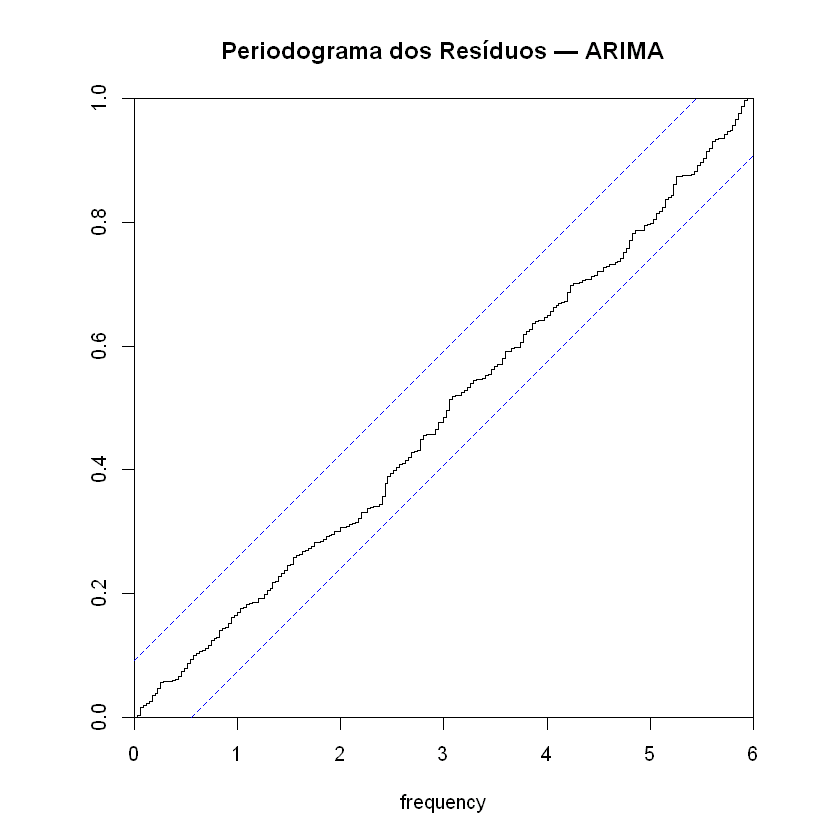


	Ljung-Box test

data:  Residuals from ARIMA(3,0,2)(0,1,1)[12] with drift
Q* = 16.745, df = 18, p-value = 0.5407

Model df: 6.   Total lags used: 24

  -> Figura salva: figuras/11_diagnostico_arima.png 


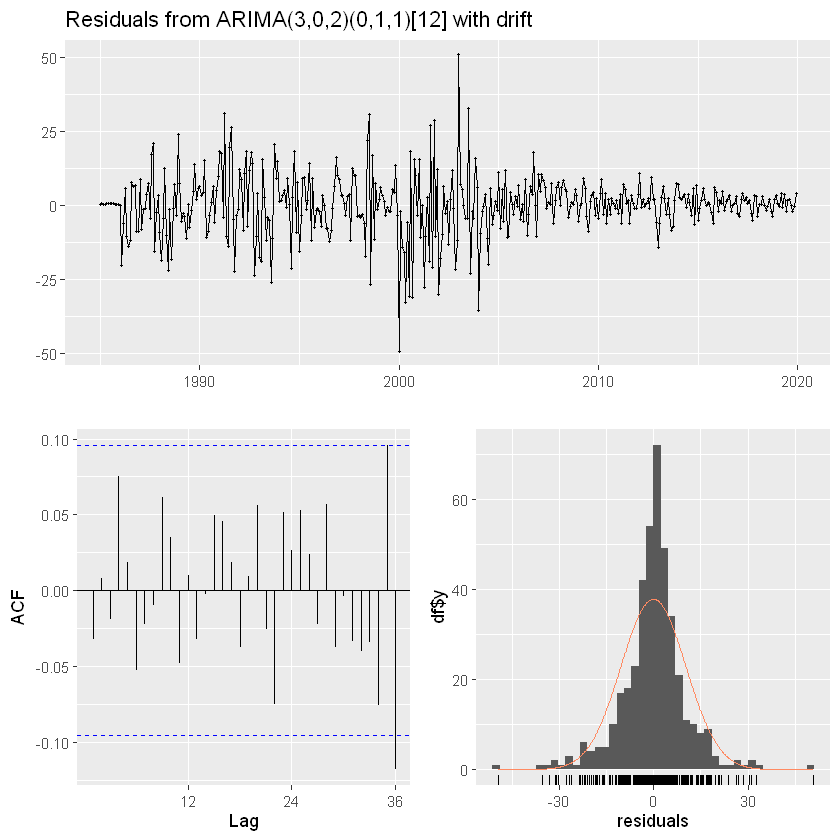

In [36]:
# --- 5d. Box-Jenkins — ARIMA / SARIMA (seleção automática por AIC) ---
cat("============================================================\n")
cat(" ARIMA — Metodologia Box-Jenkins (auto.arima)\n")
cat("============================================================\n")
modelo_arima <- auto.arima(ts_treino)
summary(modelo_arima)
cpgram(modelo_arima$residuals, main = "Periodograma dos Resíduos — ARIMA")
salvar_fig("10_residuos_arima.png")
checkresiduals(modelo_arima)
salvar_fig("11_diagnostico_arima.png", height = 900)


 ETS — Espaço de Estados


ETS(M,N,M) 

Call:
ets(y = ts_treino)

  Smoothing parameters:
    alpha = 0.3354 
    gamma = 0.3939 

  Initial states:
    l = 343.0999 
    s = 0.935 0.9991 1.0118 1.0773 1.1088 1.0325
           1.0651 0.9898 0.8371 0.9911 1.0385 0.9139

  sigma:  0.0406

     AIC     AICc      BIC 
4583.297 4584.485 4643.901 

Training set error measures:
                     ME     RMSE      MAE        MPE     MAPE      MASE
Training set -0.8962762 11.55287 8.225752 -0.4015381 2.890837 0.6781055
                  ACF1
Training set 0.3086003

  -> Figura salva: figuras/12_residuos_ets.png 


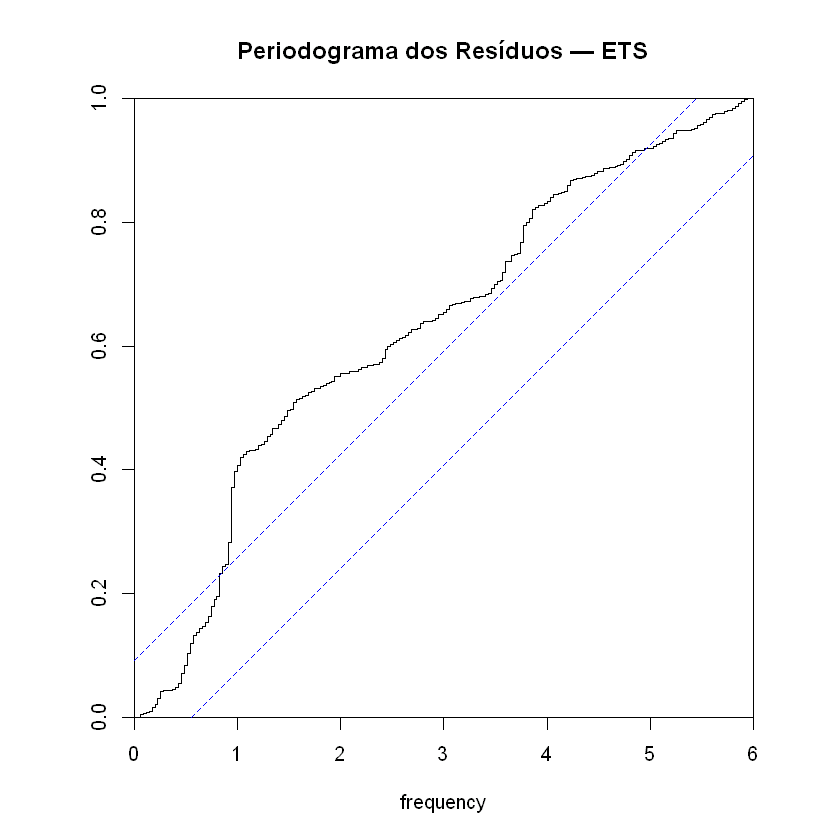


	Ljung-Box test

data:  Residuals from ETS(M,N,M)
Q* = 213.75, df = 24, p-value < 2.2e-16

Model df: 0.   Total lags used: 24

  -> Figura salva: figuras/13_diagnostico_ets.png 


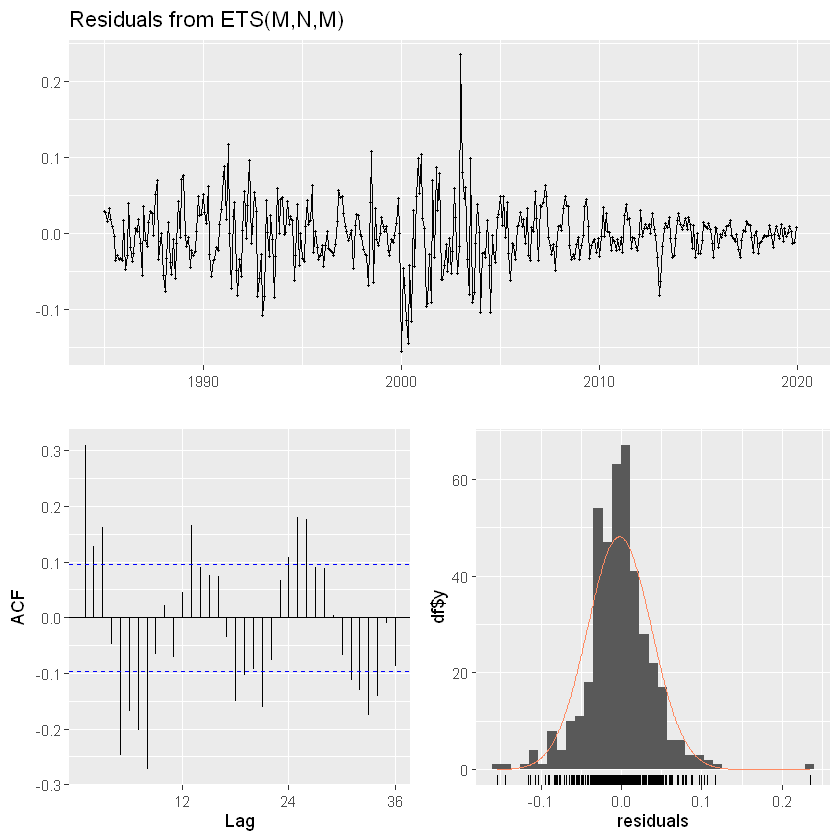

In [37]:
# --- 5e. Espaço de Estados (ETS) ---
cat("============================================================\n")
cat(" ETS — Espaço de Estados\n")
cat("============================================================\n")
modelo_ets <- ets(ts_treino)
summary(modelo_ets)
cpgram(modelo_ets$residuals, main = "Periodograma dos Resíduos — ETS")
salvar_fig("12_residuos_ets.png")
checkresiduals(modelo_ets)
salvar_fig("13_diagnostico_ets.png", height = 900)


In [38]:
# ==============================================================================
# 6. COMPARAÇÃO DOS MODELOS — AIC e RMSE
# ==============================================================================

# Gerar previsões de todos os modelos para o período de teste
prev_ses   <- forecast(modelo_ses,   h = horizonte)
prev_holt  <- forecast(modelo_holt,  h = horizonte)
prev_hw    <- forecast(modelo_hw,    h = horizonte)
prev_arima <- forecast(modelo_arima, h = horizonte)
prev_ets   <- forecast(modelo_ets,   h = horizonte)

# --- 6a. Comparação por AIC (qualidade do ajuste na base de treino) ---
# Menor AIC = melhor equilíbrio entre ajuste e parcimônia
aic_valores <- c(
  SES          = modelo_ses$model$aic,
  Holt         = modelo_holt$model$aic,
  Holt_Winters = modelo_hw$model$aic,
  ARIMA        = AIC(modelo_arima),
  ETS          = modelo_ets$aic
)

tabela_aic <- data.frame(
  Modelo = names(aic_valores),
  AIC    = round(aic_valores, 2),
  row.names = NULL
)
tabela_aic <- tabela_aic[order(tabela_aic$AIC), ]

cat("======================================================\n")
cat(" Tabela AIC — Comparação na Base de TREINO\n")
cat(" (menor valor = melhor modelo)\n")
cat("======================================================\n")
print(tabela_aic, row.names = FALSE)
cat("\nMelhor modelo por AIC:", tabela_aic$Modelo[1], "\n\n")

# --- 6b. Comparação por RMSE na base de TESTE ---
# Extrai o RMSE da linha "Test set" retornada por accuracy()
get_rmse_teste <- function(prev_obj, ts_teste) {
  acc <- accuracy(prev_obj, ts_teste)
  return(acc["Test set", "RMSE"])
}

rmse_valores <- c(
  SES          = get_rmse_teste(prev_ses,   ts_teste),
  Holt         = get_rmse_teste(prev_holt,  ts_teste),
  Holt_Winters = get_rmse_teste(prev_hw,    ts_teste),
  ARIMA        = get_rmse_teste(prev_arima, ts_teste),
  ETS          = get_rmse_teste(prev_ets,   ts_teste)
)

tabela_rmse <- data.frame(
  Modelo = names(rmse_valores),
  RMSE   = round(rmse_valores, 4),
  row.names = NULL
)
tabela_rmse <- tabela_rmse[order(tabela_rmse$RMSE), ]

cat("======================================================\n")
cat(" Tabela RMSE — Comparação na Base de TESTE (2020–2024)\n")
cat(" (menor valor = melhor capacidade preditiva)\n")
cat("======================================================\n")
print(tabela_rmse, row.names = FALSE)
cat("\nMelhor modelo por RMSE:", tabela_rmse$Modelo[1], "\n")

# --- 6c. Questão central do trabalho ---
cat("\n=== RESPOSTA À QUESTÃO DE PESQUISA ===\n")
cat("Melhor modelo (AIC  - modelagem):", tabela_aic$Modelo[1],  "\n")
cat("Melhor modelo (RMSE - previsão) :", tabela_rmse$Modelo[1], "\n")
if (tabela_aic$Modelo[1] == tabela_rmse$Modelo[1]) {
  cat("→ SIM: o melhor modelo em AIC também é o melhor em RMSE de previsão.\n")
} else {
  cat("→ NÃO: o melhor modelo em AIC difere do melhor em RMSE de previsão.\n")
}


 Tabela AIC — Comparação na Base de TREINO
 (menor valor = melhor modelo)
       Modelo     AIC
        ARIMA 3094.43
          ETS 4583.30
 Holt_Winters 4681.66
          SES 4831.17
         Holt 4836.41

Melhor modelo por AIC: ARIMA 

 Tabela RMSE — Comparação na Base de TESTE (2020–2024)
 (menor valor = melhor capacidade preditiva)
       Modelo    RMSE
          SES 51.3677
          ETS 53.2764
         Holt 57.7341
 Holt_Winters 59.3243
        ARIMA 61.7182

Melhor modelo por RMSE: SES 

=== RESPOSTA À QUESTÃO DE PESQUISA ===
Melhor modelo (AIC  - modelagem): ARIMA 
Melhor modelo (RMSE - previsão) : SES 
→ NÃO: o melhor modelo em AIC difere do melhor em RMSE de previsão.


Melhor modelo por RMSE: SES 

  -> Figura salva: figuras/14_previsao_melhor_modelo.png 


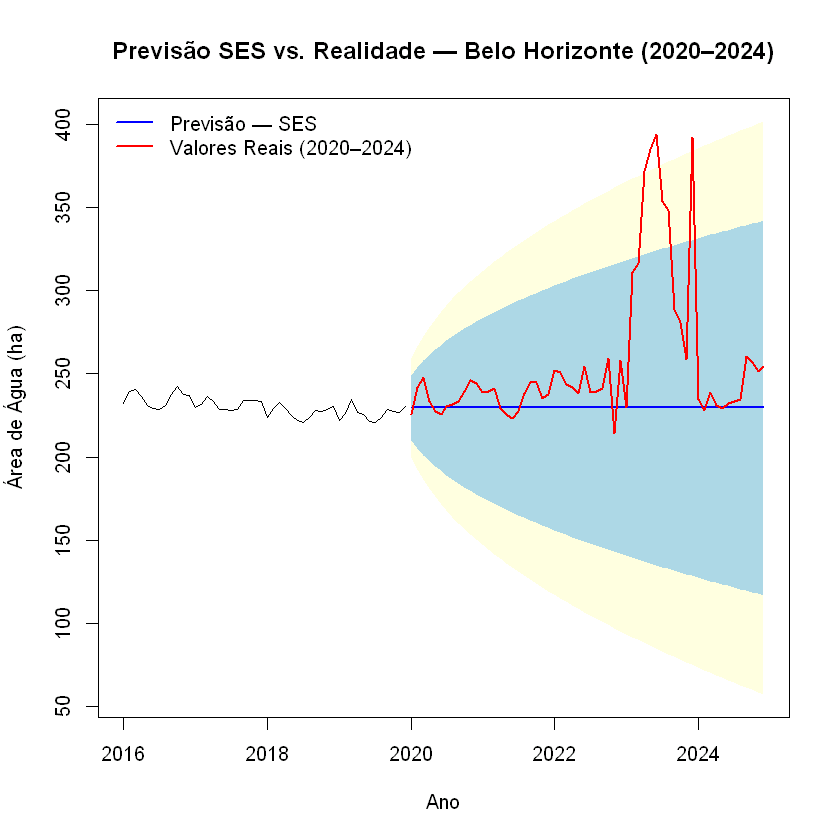

  -> Figura salva: figuras/15_comparativo_modelos.png 

=== Figuras salvas em: figuras/ ===


[1] "01_serie_completa.png"         "02_periodograma_integrado.png"
 [3] "03_decomposicao.png"           "04_residuos_ses.png"          
 [5] "05_diagnostico_ses.png"        "06_residuos_holt.png"         
 [7] "07_diagnostico_holt.png"       "08_residuos_hw.png"           
 [9] "09_diagnostico_hw.png"         "10_residuos_arima.png"        
[11] "11_diagnostico_arima.png"      "12_residuos_ets.png"          
[13] "13_diagnostico_ets.png"        "14_previsao_melhor_modelo.png"
[15] "15_comparativo_modelos.png"

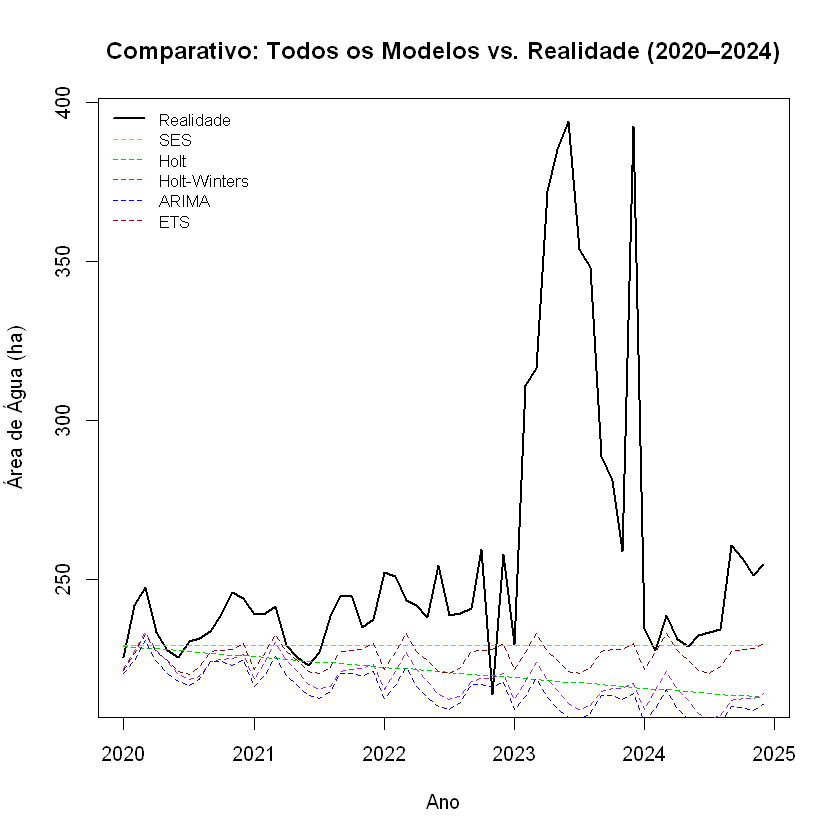

In [39]:
# ==============================================================================
# 7. PREVISÃO — Melhor Modelo vs. Realidade (2020–2024)
# ==============================================================================

# Identificar o melhor modelo por RMSE no teste
melhor_nome <- tabela_rmse$Modelo[1]
cat("Melhor modelo por RMSE:", melhor_nome, "\n\n")

# Mapear nome para objeto de previsão
lista_prev <- list(
  SES          = prev_ses,
  Holt         = prev_holt,
  Holt_Winters = prev_hw,
  ARIMA        = prev_arima,
  ETS          = prev_ets
)
melhor_prev <- lista_prev[[melhor_nome]]

# Gráfico: série de treino (últimos 48 meses) + previsão + valores reais do teste
plot(melhor_prev,
     main      = paste0("Previsão ", melhor_nome, " vs. Realidade — Belo Horizonte (2020–2024)"),
     ylab      = "Área de Água (ha)", xlab = "Ano",
     include   = 48,
     shadecols = c("lightyellow", "lightblue"),
     fcol      = "blue", flwd = 2)
lines(ts_teste, col = "red", lwd = 2)
legend("topleft",
       legend = c(paste("Previsão —", melhor_nome), "Valores Reais (2020–2024)"),
       col    = c("blue", "red"), lty = 1, lwd = 2, bty = "n")
salvar_fig("14_previsao_melhor_modelo.png")

# Gráfico comparativo: todos os modelos vs. realidade
plot(ts_teste,
     main = "Comparativo: Todos os Modelos vs. Realidade (2020–2024)",
     ylab = "Área de Água (ha)", xlab = "Ano",
     col  = "black", lwd  = 2, type = "l")
lines(prev_ses$mean,   col = "orange",  lty = 2, lwd = 1.5)
lines(prev_holt$mean,  col = "green3",  lty = 2, lwd = 1.5)
lines(prev_hw$mean,    col = "purple",  lty = 2, lwd = 1.5)
lines(prev_arima$mean, col = "blue",    lty = 2, lwd = 1.5)
lines(prev_ets$mean,   col = "darkred", lty = 2, lwd = 1.5)
legend("topleft",
       legend = c("Realidade", "SES", "Holt", "Holt-Winters", "ARIMA", "ETS"),
       col    = c("black", "orange", "green3", "purple", "blue", "darkred"),
       lty    = c(1, 2, 2, 2, 2, 2), lwd = c(2, 1.5, 1.5, 1.5, 1.5, 1.5),
       bty    = "n", cex = 0.85)
salvar_fig("15_comparativo_modelos.png")

cat("\n=== Figuras salvas em: figuras/ ===\n")
list.files("figuras")
